# EEG prior / reconstruction baseline

This report documents the completed prior-only run in the current checkout. It is a baseline for the simplified implementation, not a direct reproduction of the EEG-Guided Diffusion paper. The paper comparison requires additional reconstruction components that are not enabled here.

The primary learned-model checkpoint was selected by validation prior cosine (`eval/val/prior/pred_cos`). Reconstruction metrics are computed separately on the nine highlighted test examples.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
RUN_DIR = PROJECT_ROOT / 'experiments/eeg_prior/20260831_134809/train_eeg-20260831_134844/version_0'
METRICS_PATH = RUN_DIR / 'test/test_metrics.csv'
metrics = pd.read_csv(METRICS_PATH)
metrics['metric'] = metrics['metric'].str.removeprefix('eval/test/prior/recon/').str.replace('eval/test/prior/pred_cos', 'prior_cosine')
metrics = metrics.rename(columns={'metric': 'metric', 'value': 'value'})
metrics

,metric,value
0,prior_cosine,0.633960
1,pixcorr,0.097220
2,ssim,0.308554
3,alex2,0.722222
4,alex5,0.888889
5,inceptionv3,0.638889
6,clip,0.791667
7,efficientnet,0.900438
8,swav,0.587954


## Protocol

| Component | Current baseline |
|---|---|
| Training mode | Prior-only (`do_align=false`, `do_recon=true`) |
| EEG encoder | ATMS initialized from completed alignment checkpoint |
| Prior target | `clip_vith14` image latent |
| Trainable modules | EEG encoder and diffusion prior |
| Batch / workers | 32 / 4 |
| Checkpoint selection | Maximum `eval/val/prior/pred_cos` |
| Reconstruction evaluation | Separate test script, nine highlighted examples |
| TensorBoard | Training output only |

In [2]:
summary = metrics.assign(metric=metrics['metric'].replace({
    'prior_cosine': 'Prior cosine',
    'pixcorr': 'PixCorr',
    'ssim': 'SSIM',
    'alex2': 'AlexNet-2',
    'alex5': 'AlexNet-5',
    'inceptionv3': 'Inception',
    'clip': 'CLIP',
    'efficientnet': 'EfficientNet',
    'swav': 'SwAV',
})).set_index('metric').T
summary.round(5)

metric,Prior cosine,PixCorr,SSIM,AlexNet-2,AlexNet-5,Inception,CLIP,EfficientNet,SwAV
value,0.63396,0.09722,0.30855,0.72222,0.88889,0.63889,0.79167,0.90044,0.58795


## Interpretation

The current result should not be compared directly with the paper's reported reconstruction scores. The present path trains the simplified diffusion prior and then uses the repository's current IP-Adapter/SDXL-Turbo reconstruction path. Differences in model components, objective weighting, sampling, and evaluation protocol can change PixCorr, SSIM, AlexNet, and Inception substantially. CLIP and SwAV being numerically close is not evidence that the pipelines are equivalent.

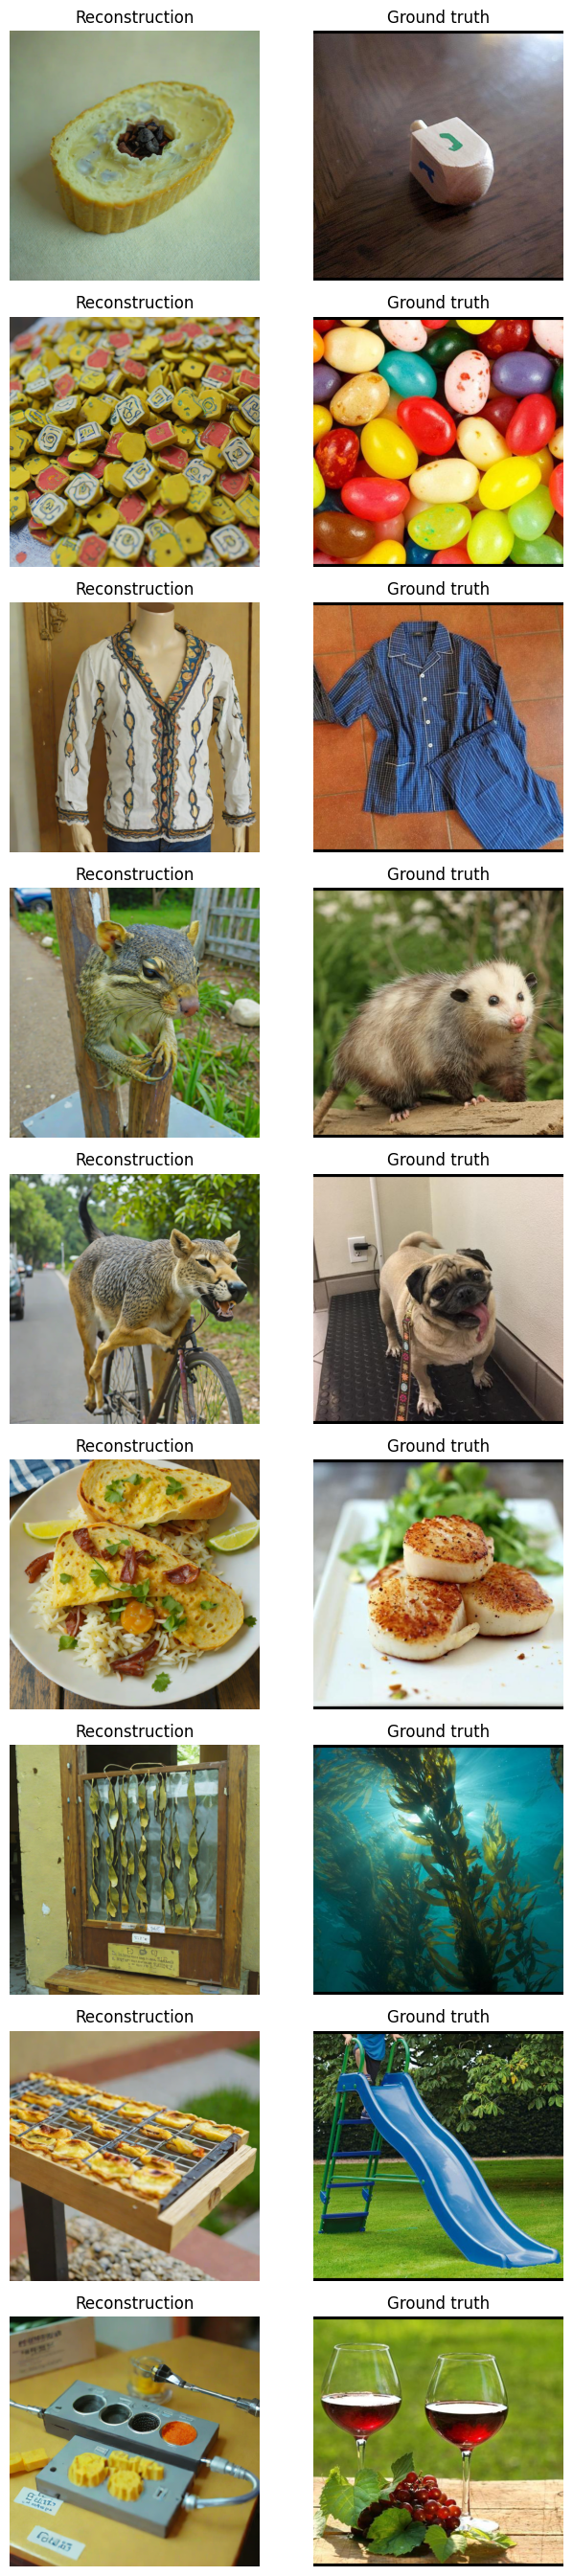

In [3]:
recon_root = RUN_DIR / 'test'
pairs = []
for recon_path in sorted(recon_root.glob('*/test/prior/recon.png')):
    gt_path = recon_path.with_name('gt.png')
    if gt_path.exists():
        pairs.append((recon_path.parent.parent.parent.name, recon_path, gt_path))
assert len(pairs) == 9, f'Expected 9 reconstruction pairs, found {len(pairs)}'
fig, axes = plt.subplots(len(pairs), 2, figsize=(7, 3 * len(pairs)))
for row, (label, recon_path, gt_path) in enumerate(pairs):
    axes[row, 0].imshow(Image.open(recon_path))
    axes[row, 1].imshow(Image.open(gt_path))
    axes[row, 0].set_ylabel(label, rotation=0, labelpad=65, va='center')
    axes[row, 0].set_title('Reconstruction')
    axes[row, 1].set_title('Ground truth')
    axes[row, 0].axis('off')
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()